#**스마트폰 센서 데이터 기반 모션 분류**
# 단계1 : 탐색적 데이터 분석

## 0.미션

### (1) 미션1
수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **기본 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature와 중요하지 않은 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.


### (2) 미션2
다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.


## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/project3/'

### (2) 라이브러리 설치 및 불러오기

* 라이브러리 로딩

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import *    # confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

* 제공 함수 생성
    * 변수 중요도를 시각화할 수 있는 함수를 제공합니다.
    * 입력 :
        * importance : 트리모델의 변수 중요도(예: model.feature_importances_)
        * names : 변수 이름 목록(예 : x_train.columns
        * result_only  : 변수 중요도 순으로 데이터프레임만 return할지, 그래프도 포함할지 결정. False이면 결과 데이터프레임 + 그래프
        * topn : 중요도 상위 n개만 표시. all 이면 전체.
    * 출력 :
        * 중요도 그래프 : 중요도 내림차순으로 정렬
        * 중요도 데이터프레임 : 중요도 내림차순으로 정렬

In [6]:
# 변수의 특성 중요도 계산하기
def plot_feature_importance(importance, names, result_only = False, topn = 'all'):
    feature_importance = np.array(importance)
    feature_name = np.array(names)

    data={'feature_name':feature_name,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    #변수의 특성 중요도 순으로 정렬하기
    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    #변수의 특성 중요도 그래프로 그리기
    if result_only == False :
        plt.figure(figsize=(10,20))
        sns.barplot(x='feature_importance', y='feature_name', data = fi_df)

        plt.xlabel('importance')
        plt.ylabel('feature name')
        plt.grid()

    return fi_df

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

In [150]:
# 학습 데이터만 불러와서 진행하기 (test data X)
# feature.csv 를 가지고 뭘 해봐도 되는데 안해도 아무 상관이 없다.

In [7]:
df_train = pd.read_csv(path + 'data01_train.csv')
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS


In [8]:
df_test = pd.read_csv(path + 'data01_test.csv')
df_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,22,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,15,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,22,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,8,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,5,STANDING


In [9]:
features = pd.read_csv(path + 'features.csv')
features.head()

,sensor,agg,axis,feature_name
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z
3,tBodyAcc,std(),X,tBodyAcc-std()-X
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y


In [10]:
# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

## 2.데이터 분석 : 기본정보 살펴보기

### (1) 기본정보 확인하기


* **세부 요구사항**
    - 불러온 데이터의 형태, 기초통계량, 정보 등을 확인합니다.

In [11]:
# 전체 데이터의 행, 열 개수 확인
df_train.shape   # 행 5881개, 열 562개

(5881, 562)

In [12]:
df_train.info()

# 562개의 컬럼
# float형 561개, object형 1개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [157]:
# 전체 데이터의 수치형 변수 분포 확인
df_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [13]:
# 전체 데이터의 모든 변수 확인
df_train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'Activity'],
      dtype='object', length=562)

In [158]:
# df_train.isnull().sum()

# 컬럼 수가 너무 많아서 null값을 모두 확인할 수 없음
# 그래서 0보다 큰 컬럼만 출력하도록 하여 확인
# 그 결과 null값 존재하지 않음

null_columns = df_train.isnull().sum()
null_columns[null_columns > 0]

,0


### (2) 목표 변수 확인하기

* **세부 요구사항**
    - target인 'Activity'에 대해 단변량 분석을 수행합니다.
    - 범주의 종류, 범주별 빈도수 및 비율 등

In [14]:
# 범주별 빈도수 확인
df_train['Activity'].value_counts()

,count
Activity,
LAYING,1115
STANDING,1087
SITTING,1032
WALKING,998
WALKING_UPSTAIRS,858
WALKING_DOWNSTAIRS,791


In [160]:
# 범주의 종류
df_train['Activity'].unique()

array(['STANDING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS', 'SITTING'], dtype=object)

In [162]:
# Activity라는 컬럼에 있는 각 고유 값들의 비율을 계산하고 출력하는 코드
df_train['Activity'].value_counts(normalize=True)

# 클래스 불균형 문제는 없어보인다. -> 비율로 볼 때 크게 차이가 없어보인다.
# 이 정도 비율이면 잘 분포되어 있는 것이다.

# LAYING(누워있는), STANDING(일어서있는), SITTING(앉아있는) 것의 비율이 상대적으로 약간 높다. -> 정적 행동의 비율이 더 높다.

,proportion
Activity,
LAYING,0.189594
STANDING,0.184833
SITTING,0.175480
WALKING,0.169699
WALKING_UPSTAIRS,0.145894
WALKING_DOWNSTAIRS,0.134501


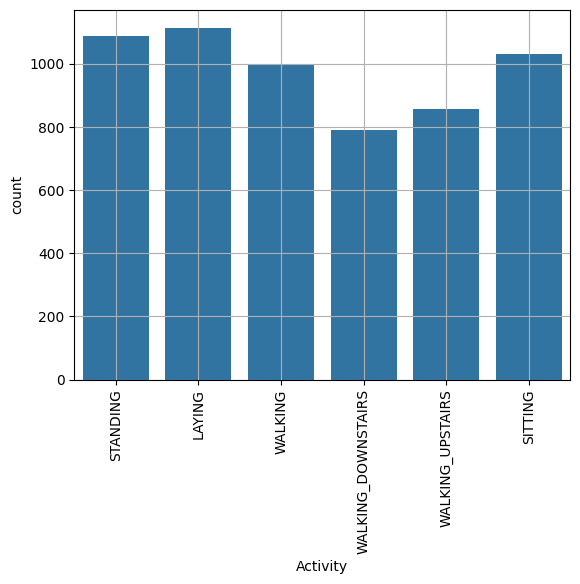

In [23]:
sns.countplot(data=df_train, x = 'Activity')
plt.xticks(rotation=90)
plt.grid()
plt.show()

## 3.미션1 : 데이터 분석1

수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **트리 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.
* 3) **각 feature 그룹별 중요도**도 파악해보며 EDA를 수행  
    * Feature 이름에는 계층구조를 담고 있습니다. 그렇다 보니 feature들을 적절하게 그룹으로 묶을 수 있습니다.
    * 참고로, feature 그룹의 중요도는 개별 feature 중요도의 합으로 계산할 수 있습니다.

### (1) 기본모델링 + 변수중요도 추출

* **세부 요구사항**
    - 모델링을 위한 기본 전처리를 수행합니다.
        - 주어진 데이터에서는 x, y로 나누고 train과 validation 분할 수행
    - 트리기반 알고리즘을 이용하여 모델링을 합니다.
        - 랜덤포레스트 권장 : 랜덤포레스트는 튜닝 없이 하이퍼파리미터의 기본값로도 적절한 성능의 모델을 생성할 수 있습니다.
    - 변수 중요도 추출
        - 사용자정의함수로 생성한 plot_feature_importance 을 이용
        - 변수중요도 파악및 결과 저장

#### 1) 데이터 전처리

In [58]:
# x, y 분리
target = 'Activity'
x1 = df_train.drop(target,axis=1)
y1 = df_train.loc[:, target]

In [59]:
# 타겟변수인 'Activity'만 범주형이고, 나머지는 수치형이므로 가변수화는 필요 X

In [60]:
# 학습용, 검증용 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x1, y1, test_size=0.3, random_state=42)

#### 2) 모델링

In [61]:
# 선언하기
# max_depth : 트리의 촤대 깊이
# n_estimators : 만들어질 decision tree 개수 지정/ 많이 지정할수록 성능이 좋아질 것으로 기대할 수 있지만 무조건 그런 것은 아니다./ 너무 늘리면 학습 속도 느려짐
model = RandomForestClassifier(random_state=1, n_estimators=100)  # max_depth=5

# 학습하기
model.fit(x_train, y_train)

# 예측하기
y_pred = model.predict(x_val)

In [62]:
#평가
print('accuracy :',accuracy_score(y_val, y_pred))
print('='*60)
print(confusion_matrix(y_val, y_pred))
print('='*60)
print(classification_report(y_val, y_pred))

## confusion_matrix 해석
# 행: 실제 클래스
# 열: 예측된 클래스

# 1행 334 : 334개의 샘플 중 334개가 올바르게 1번째 클래스로 분류됨. 잘못 분류된 경우는 X
# 2행 : 297개의 샘플이 올바르게 2번 클래스로 분류됨. 13개가 3번째 클래스로 잘못 분류됨
# 3행 : 229개의 샘플이 올바르게 3번 클래스로 분류됨. 14개가 2번째 클래스로 잘못 분류됨
# ...

# ----------------------------------------------------------------------
# 3줄씩 4등분해서 봤을 때, 위 3개 행은 '정적 데이터'이고, 아래 3줄은 '동적 데이터'이다.
# 마찬가지로, 왼쪽 3개의 열은 '정적 데이터'이고, 이후 나머지 3개의 열은 '동적 데이터'이다.

# 그래서!!! 모델을 학습할 때, 정/동적 데이터를 나눠서 각각 모델을 학습시키고, 이 두개의 모델을 통합시키는 방법이 있다.
# 이 방법이 더 좋은 이유는,
# '정적 데이터'는 변화가 없으므로 특정 패턴을 잘 학습하는 모델이 유리하다.
# '동적 데이터'는 시계열적 특성을 반영한 학습이 필요하다.
# --> 두 데이터 유형에 맞는 모델을 각각 학습시킴으로써 각 모델이해당 데이터 유형의 특성을 더 잘 파악하게 한다.

# 모델 복잡성 감소, 노이즈 감소(서로 다른 성격을 가지는 데이터를 동시에 학습시킬 시 발생할 수 있음)의 문제를 줄일 수 있다.
# 뿐만 아니라, 모델을 나눠서 학습시킴으로써 정/동적 데이터 각각에 대한 모델의 예측 성능과 중요도를 따로 평가할 수 있다.

accuracy : 0.973371104815864
[[334   0   0   0   0   0]
 [  0 297  13   0   0   0]
 [  0  14 299   0   0   0]
 [  0   0   0 286   3   3]
 [  0   0   0   4 232   3]
 [  0   0   0   1   6 270]]
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       334
           SITTING       0.95      0.96      0.96       310
          STANDING       0.96      0.96      0.96       313
           WALKING       0.98      0.98      0.98       292
WALKING_DOWNSTAIRS       0.96      0.97      0.97       239
  WALKING_UPSTAIRS       0.98      0.97      0.98       277

          accuracy                           0.97      1765
         macro avg       0.97      0.97      0.97      1765
      weighted avg       0.97      0.97      0.97      1765



#### 3) 변수 중요도 추출

- 모델 학습만 하면 변수 중요도를 추출할 수 있다!!   
- 하지만 **이 변수 중요도는 모델을 설명하는 것**이다. (실제 상황을 설명하는 것 X)
- **모델에서의 변수 중요도를 뽑은 것!**
---
* 참고) 여기에 나온 '변수 중요도'는 각 Decision Tree의 변수 중요도를 합친 것이다.

,feature_name,feature_importance
0,"angle(X,gravityMean)",0.037592
1,tGravityAcc-mean()-X,0.029307
2,tGravityAcc-min()-X,0.028884
3,tGravityAcc-energy()-X,0.028812
4,tGravityAcc-min()-Y,0.023805
...,...,...
556,fBodyBodyAccJerkMag-min(),0.000094
557,tBodyAcc-max()-Y,0.000092
558,fBodyAcc-min()-Y,0.000089
559,"tBodyAcc-arCoeff()-Y,1",0.000038


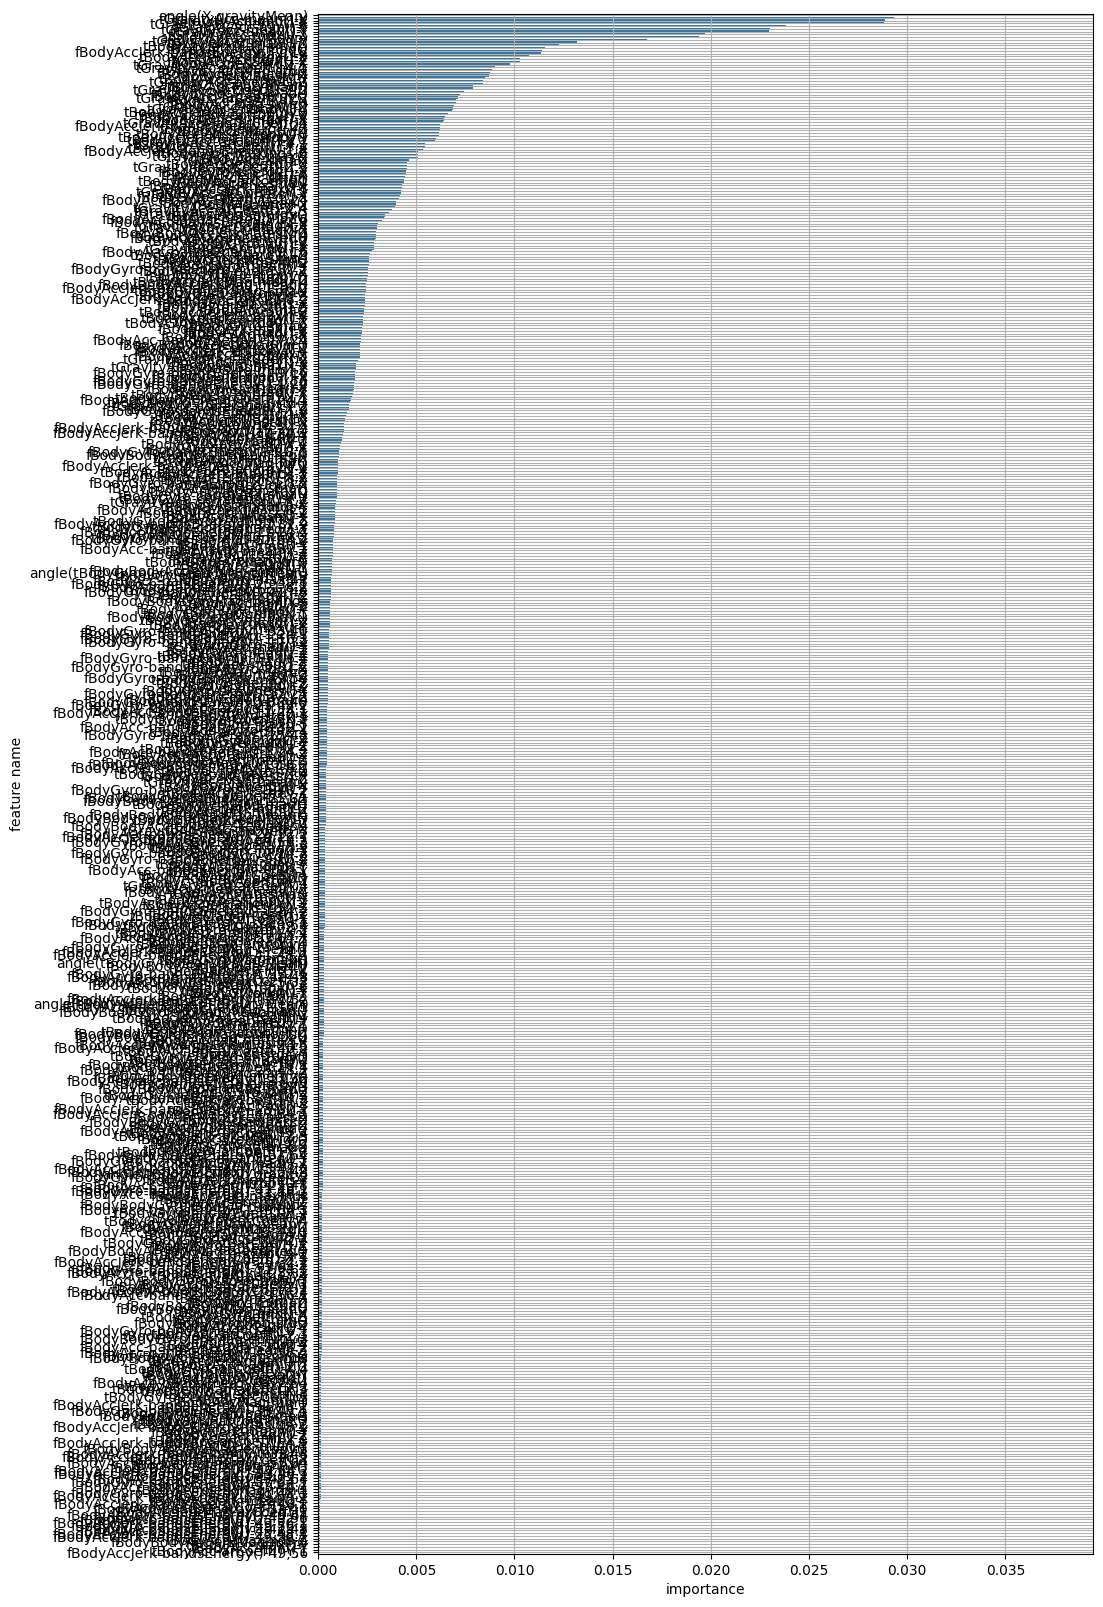

In [67]:
r0 = plot_feature_importance(model.feature_importances_, list(x_train), result_only = False)  # topn = 'all'
r0

### (2) 중요도 기반 feature 분석

* **세부 요구사항**
    - 상위 n, 하위 m 개의 변수를 선정
    - 선정된 변수(feature)와 target 간의 관계를 kdeplot으로 그리기

#### 1) 상위 5, 하위 5개 변수 선정

In [68]:
# 중요도 상위 5
r0.head(5)

,feature_name,feature_importance
0,"angle(X,gravityMean)",0.037592
1,tGravityAcc-mean()-X,0.029307
2,tGravityAcc-min()-X,0.028884
3,tGravityAcc-energy()-X,0.028812
4,tGravityAcc-min()-Y,0.023805


In [69]:
# 중요도 하위 5
r0.tail(5)

,feature_name,feature_importance
556,fBodyBodyAccJerkMag-min(),0.000094
557,tBodyAcc-max()-Y,0.000092
558,fBodyAcc-min()-Y,0.000089
559,"tBodyAcc-arCoeff()-Y,1",0.000038
560,"fBodyAccJerk-bandsEnergy()-49,56",0.000036


In [83]:
# 상위/하위 변수에 대한 분석 함수
def top_bottom_kde(col):
  plt.figure(figsize=(10,7))
  # common_norm : True인 경우 모든 그래프 면적을 합쳐서 1로 만든다. False인 경우 각 그래프의 면적이 1이 된다.
  sns.kdeplot(x=col, data=df_train, hue=target, common_norm = False)

#### 2) 상위 5개 변수에 대한 분석


> **kde plot 해석 방법**

: 주어진 데이터를 기반으로 **분포를 추정**하는 비모수적 방법    
**데이터가 특정 구간에 얼마나 집중되어 있는지**를 **시각적으로 표현**할 수 있다.   
(주어진 데이터의 확률 밀도 함수를 시각적으로 나타낸 방법)
   
- 해석 방법
1. x축과 y축     
x축: 변수의 값   
y축: 해당 값의 확률 밀도     
**y축의 값이 높을수록 해당 x값의 발생 확률이 높다.**
      

2. 분포 형태   
- 단봉 분포: 한 개의 봉우리가 있는 경우, 데이터가 특정 값 주위에 집중되어 있음을 의미   
- 다봉 분포: 여러 개의 봉우리가 있는 경우, 데이터가 여러 개의 집단으로 나누어져 있을 가능성이 높다.   
   
3. 밀도 값 해석
- y축의 값이 0인 경우 x값이 데이터에서 존재하지 않는다.
- y축 값이 높을수록 그 값 주위에서 데이터 포인트가 많이 존재함을 나타낸다.


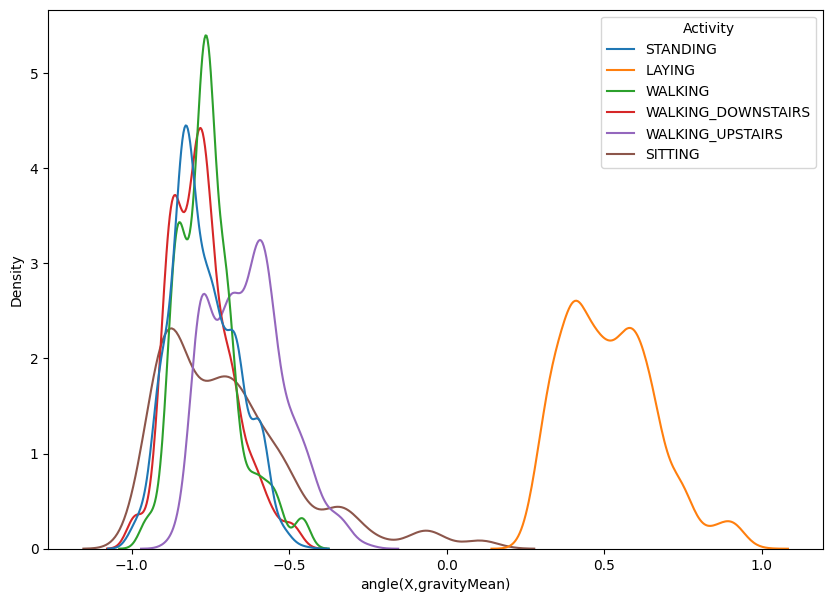

In [84]:
top_bottom_kde('angle(X,gravityMean)')

# LAYING 변수만 잘 구분했는데(분포되어 있는데), 왜 중요도가 높은 변수지?
# LAYING가 아닌 다른 변수들은 겹치는 부분이 많은데? (잘 구분하지 못했는데?)


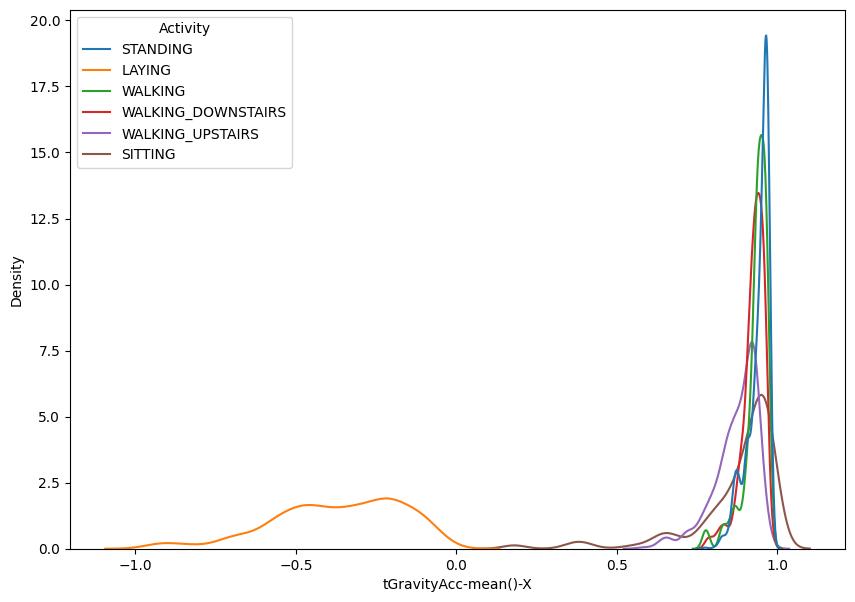

In [85]:
top_bottom_kde('tGravityAcc-mean()-X')

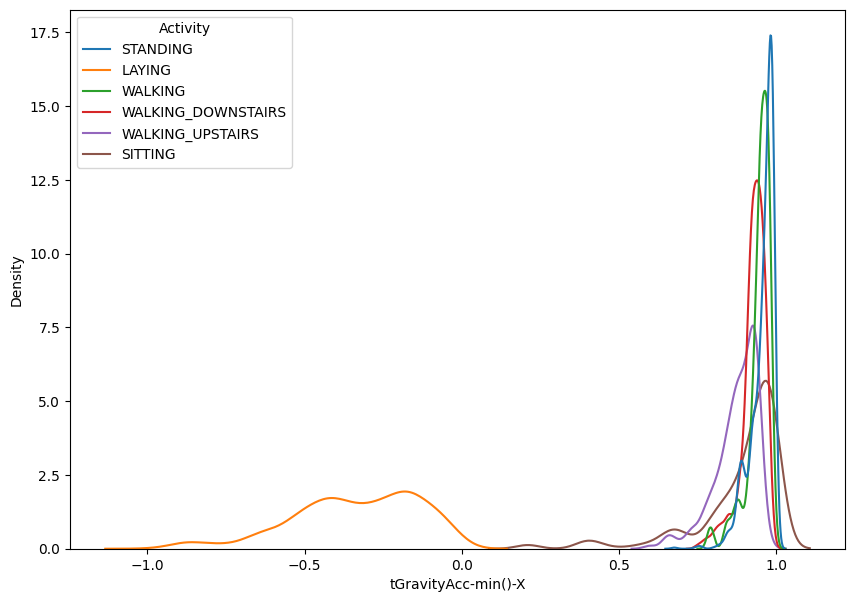

In [86]:
top_bottom_kde('tGravityAcc-min()-X')

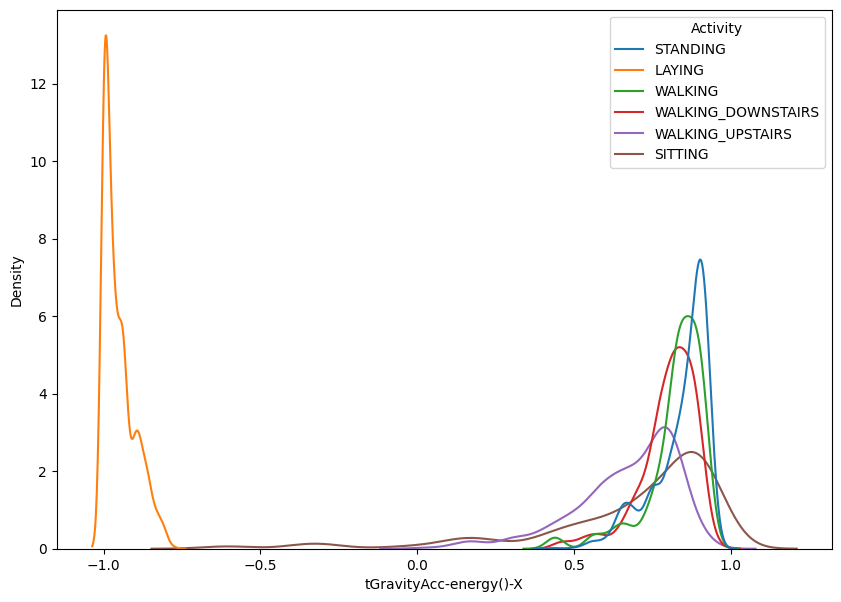

In [87]:
top_bottom_kde('tGravityAcc-energy()-X')

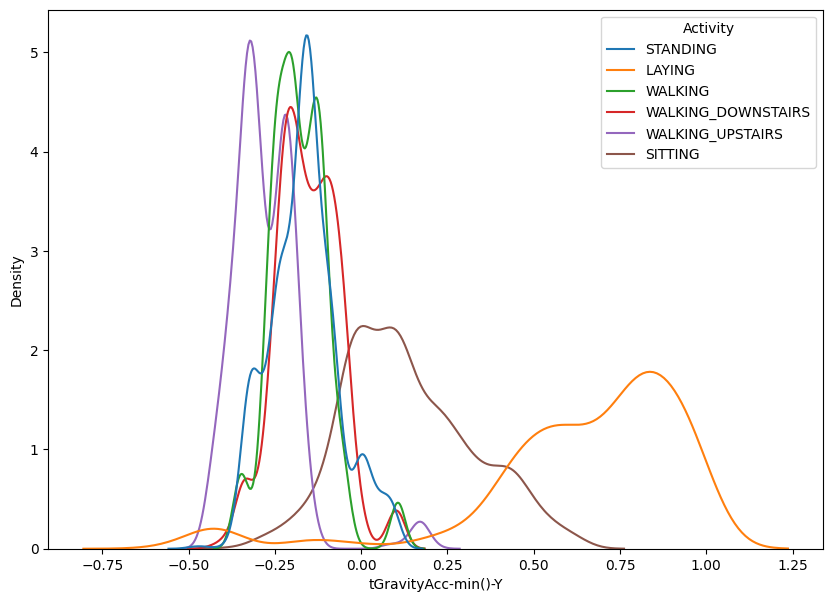

In [88]:
top_bottom_kde('tGravityAcc-min()-Y')

#### 3) 하위 5개 변수에 대한 분석

- 뾰족한 부분은 데이터가 특정 구간에 높게 분포되어 있다. 뾰족하지 않은 부분은 넓게 분포되어 있다.
- 그래프를 잘 살펴보면, **왼쪽** 뾰족한 부분은 **정적 데이터**이고, **오른쪽** 완만한 부분은 **동적 데이터**임을 알 수 있다.


> 따라서, 랜덤포레스트는 변수중요도가 낮은 변수라고 판단을 했지만, 이후에 동/정적 2 class로 변경해서 봤을 때는 의미있는 변수일 수도 있다.   
중요하지 않다고 해서 변수를 버리면 안된다!

---
그리고 정적 데이터가 거의 다 -1에 분포되어 있으므로 그래프가 정적 데이터가 매우 높게 분포하게 나온 것이다.   
**동적 데이터의 분포를 더 잘 보고 싶다면, 정적 데이터를 제외하고 봐야 한다.**

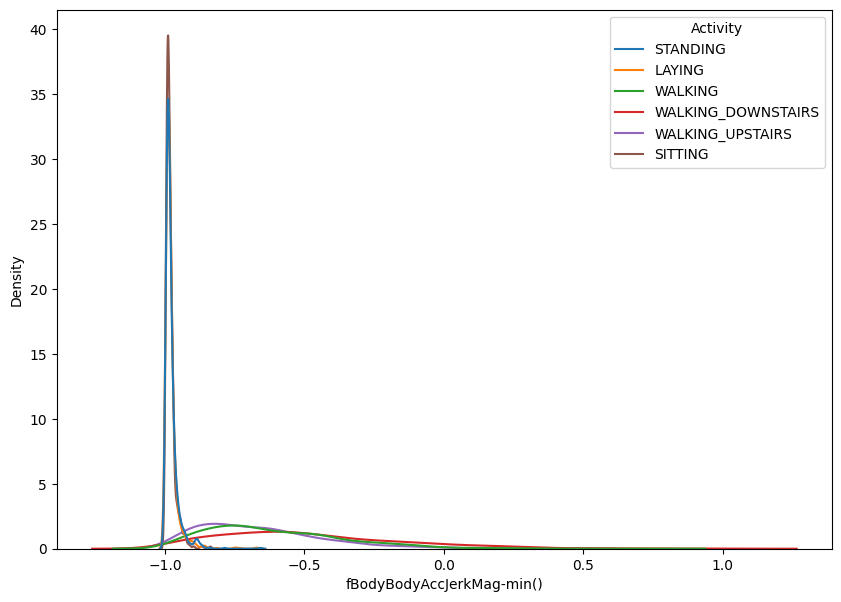

In [89]:
top_bottom_kde('fBodyBodyAccJerkMag-min()')

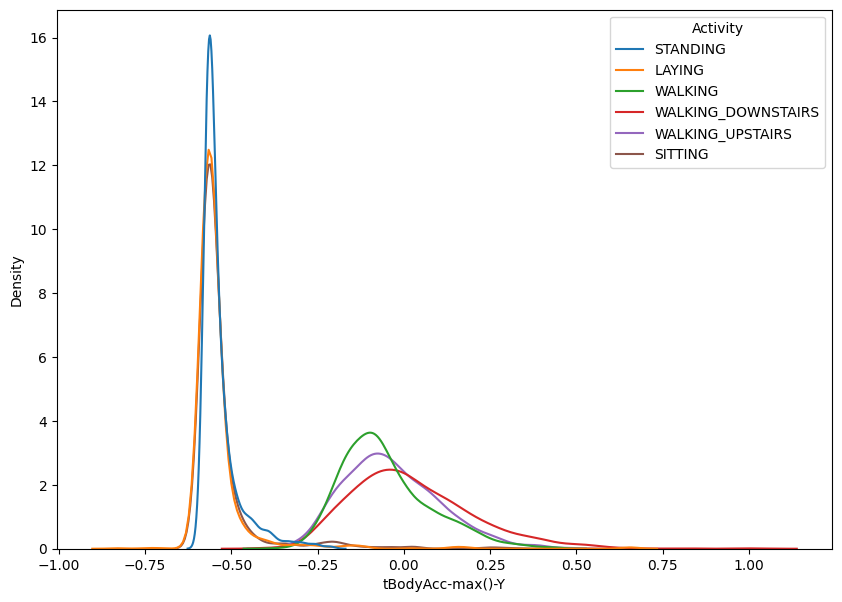

In [90]:
top_bottom_kde('tBodyAcc-max()-Y')

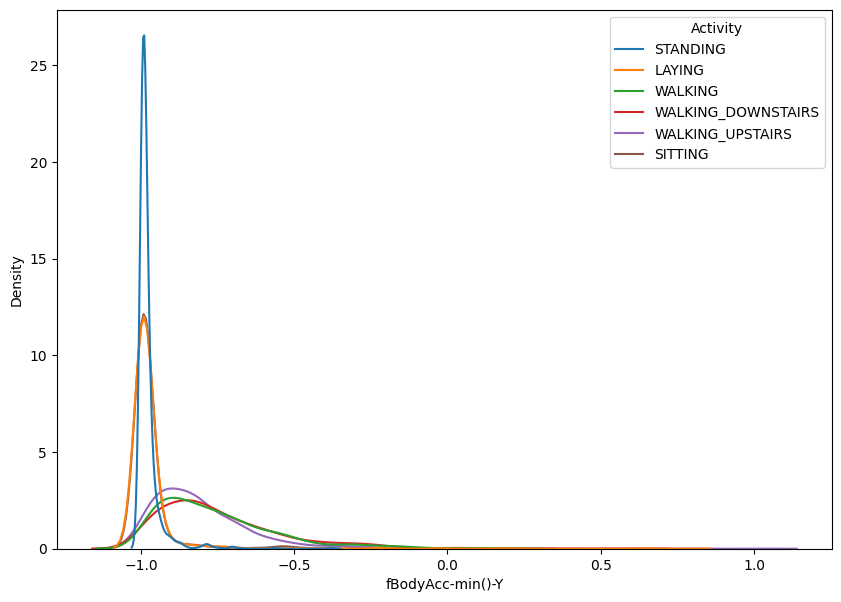

In [91]:
top_bottom_kde('fBodyAcc-min()-Y')

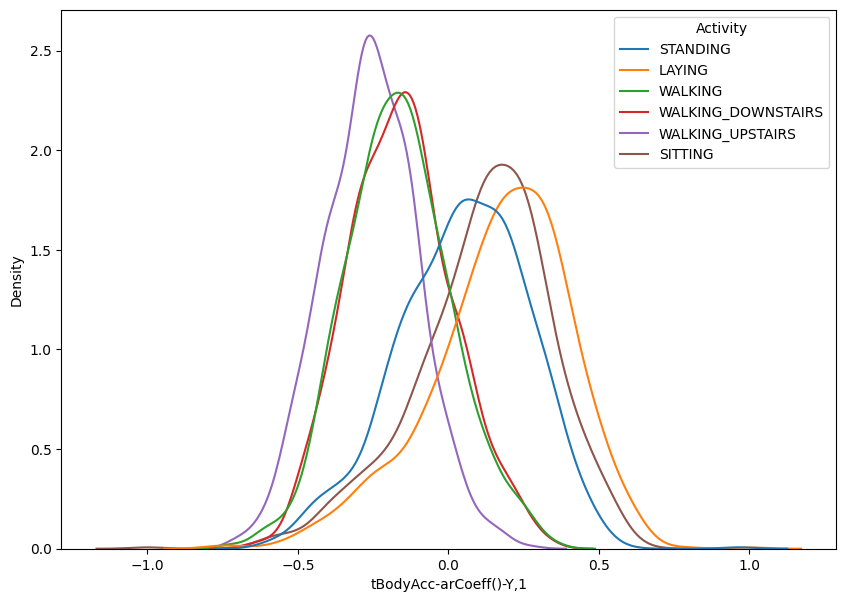

In [92]:
top_bottom_kde('tBodyAcc-arCoeff()-Y,1')

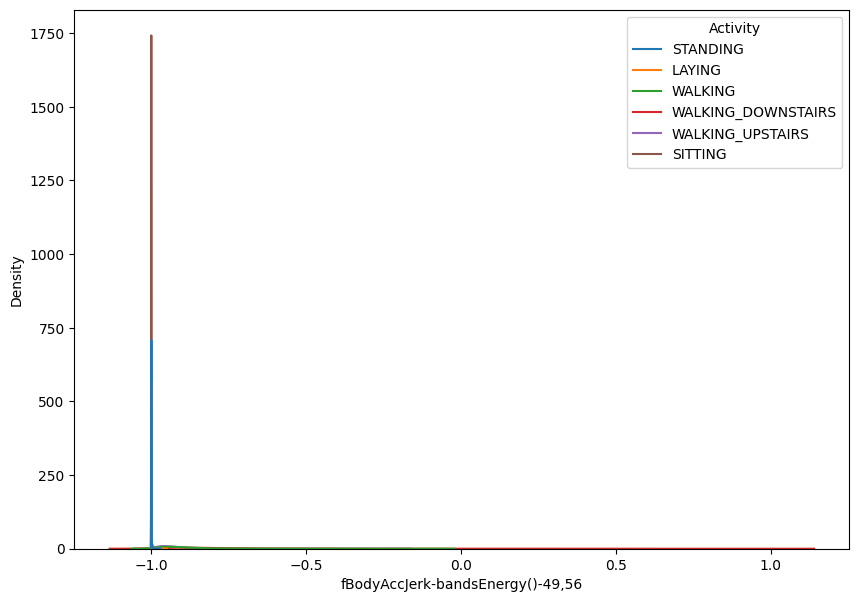

In [93]:
top_bottom_kde('fBodyAccJerk-bandsEnergy()-49,56')

## 4.미션2 : 데이터 분석2

다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.

### (1) 정적/동적 행동으로 구분하여 분석하기

* **세부 요구사항**
    - Target인 Activity를 is_dynamic 변수로 변경하시오.
        * 값 0 : STANDING, SITTING, LAYING
        * 값 1 : WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS
    - is_dynamic을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_dynamic을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_dynamic 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_dynamic 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


#### 1) is_dynamic 추가

In [94]:
# 동적 행동이면 1, 그게 아니면(정적 행동이면) 0

df_train['Activity'] = df_train['Activity'].apply(lambda x: 1 if x in ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'] else 0)
df_train.rename(columns={'Activity': 'is_dynamic'}, inplace=True)
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,1


In [95]:
df_train.tail()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",is_dynamic
5876,0.277194,-0.012389,-0.131974,-0.994046,-0.940578,-0.917337,-0.994261,-0.932830,-0.908088,-0.936219,...,-0.305772,-0.690363,-0.034888,-0.261437,-0.391477,-0.877612,-0.912365,0.114009,0.080146,0
5877,0.191568,0.013328,-0.105174,-0.126969,-0.121729,-0.327480,-0.192523,-0.109923,-0.295286,0.078644,...,-0.622617,-0.879215,0.721718,0.623151,0.866858,-0.445660,-0.690278,0.303194,-0.044188,1
5878,0.267981,-0.018348,-0.107440,-0.991303,-0.989881,-0.990313,-0.992386,-0.988852,-0.991237,-0.936099,...,-0.597610,-0.886851,0.060173,0.228739,0.684400,-0.216665,0.620363,-0.437247,-0.571840,0
5879,0.212787,-0.048130,-0.121001,-0.041373,0.052449,-0.585361,-0.100714,0.023353,-0.554707,0.219814,...,0.196921,-0.053556,0.260880,0.551742,-0.943773,-0.862899,-0.718009,0.292856,0.024920,1
5880,0.283815,-0.040658,-0.138018,-0.992662,-0.747190,-0.920248,-0.993410,-0.768055,-0.924587,-0.935871,...,-0.379740,-0.696584,0.107690,0.122242,-0.077226,-0.078091,-0.740244,0.008346,-0.146143,0


#### 2) 기본모델 생성

In [110]:
# x, is_dynamic을 이용하여 train과 validation으로 데이터 분할
target = 'is_dynamic'
x2 = df_train.drop(target,axis=1)
y2 = df_train.loc[:, target]

In [111]:
x_train, x_val, y_train, y_val = train_test_split(x2, y2, test_size=0.3, random_state=42)

In [112]:
# 선언하기
model = RandomForestClassifier(random_state=1, n_estimators=100)

# 학습하기
model.fit(x_train, y_train)

# 예측하기
y_pred = model.predict(x_val)


In [113]:
#평가
print('accuracy :',accuracy_score(y_val, y_pred))
print('='*60)
print(confusion_matrix(y_val, y_pred))
print('='*60)
print(classification_report(y_val, y_pred))

accuracy : 1.0
[[957   0]
 [  0 808]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       957
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765



#### 3) 변수중요도 상위 5개 분석

,feature_name,feature_importance
0,tBodyAccJerk-entropy()-X,0.059930
1,"fBodyAccJerk-bandsEnergy()-1,16",0.050420
2,tBodyAccJerk-mad()-X,0.049916
3,fBodyAccJerk-mad()-X,0.049726
4,tBodyAccJerk-energy()-X,0.040121
...,...,...
556,tBodyGyroMag-max(),0.000000
557,tBodyGyroMag-mad(),0.000000
558,tBodyGyroMag-std(),0.000000
559,tGravityAcc-std()-Z,0.000000


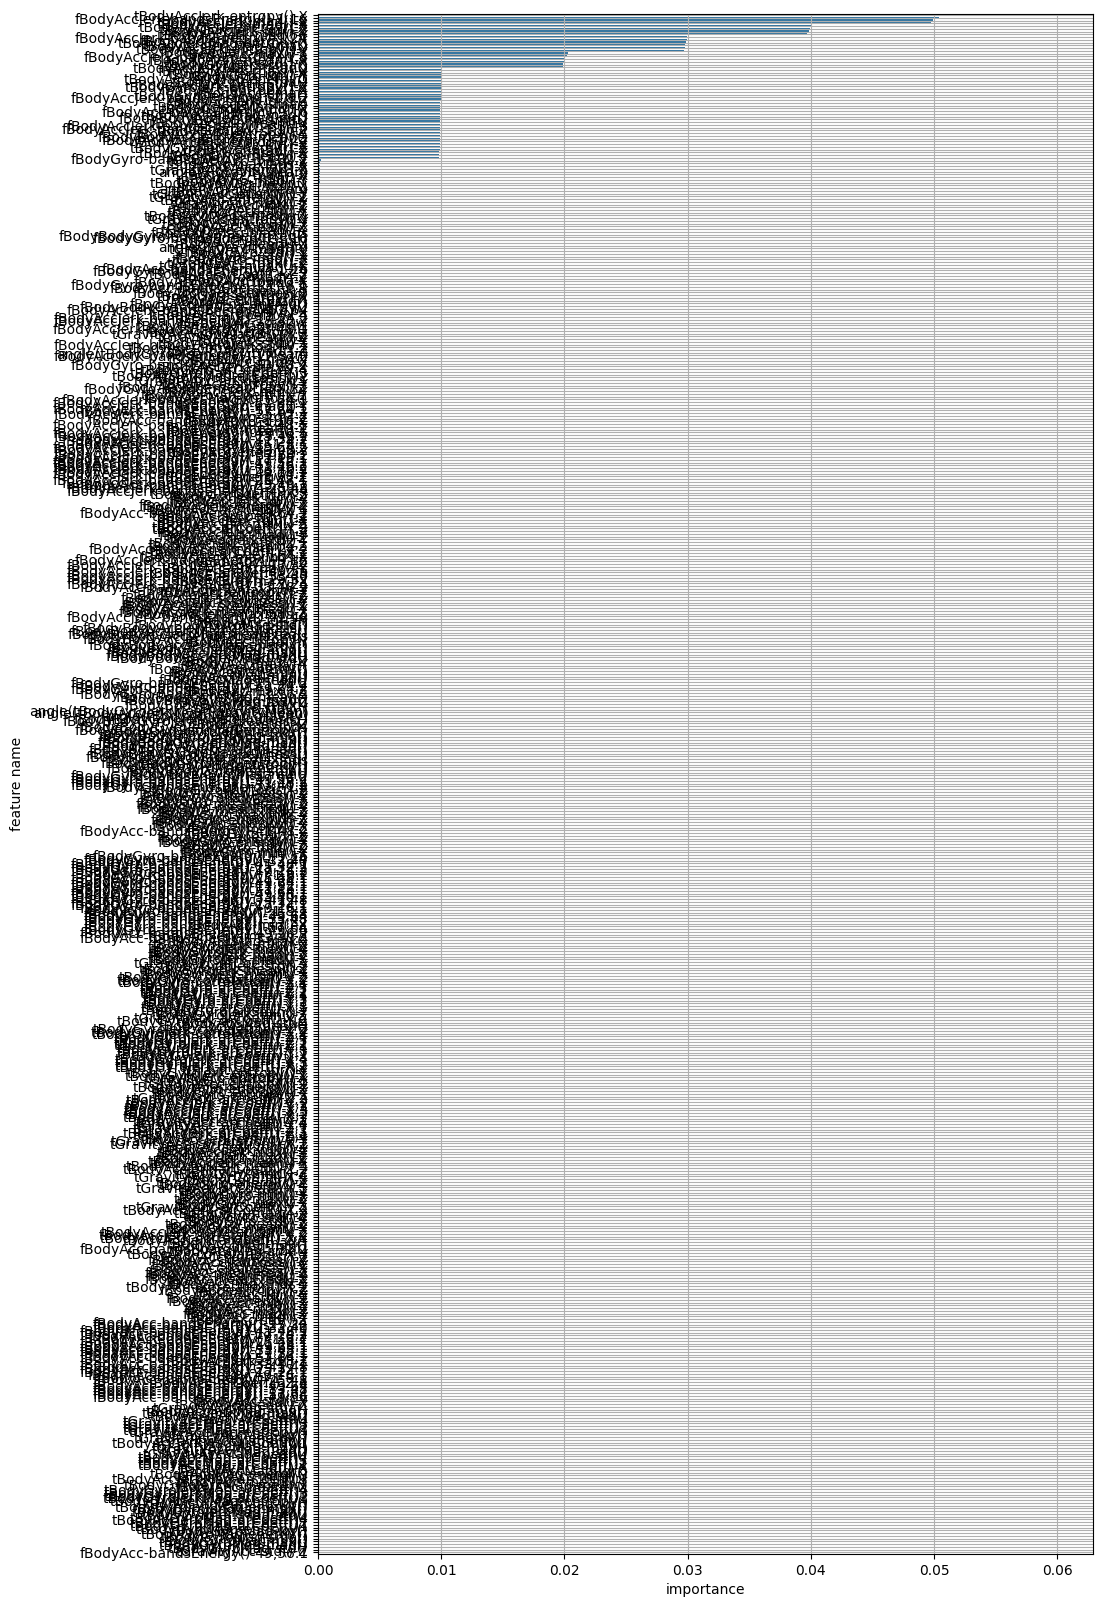

In [114]:
r_dyn = plot_feature_importance(model.feature_importances_, list(x_train), False)
r_dyn

In [115]:
# 상위 변수 선정
r_dyn.head()

,feature_name,feature_importance
0,tBodyAccJerk-entropy()-X,0.059930
1,"fBodyAccJerk-bandsEnergy()-1,16",0.050420
2,tBodyAccJerk-mad()-X,0.049916
3,fBodyAccJerk-mad()-X,0.049726
4,tBodyAccJerk-energy()-X,0.040121


In [124]:
df_train.shape

(5881, 562)

In [120]:
# 상위/하위 변수에 대한 분석 함수
def top_bottom_kde(col):
  plt.figure(figsize=(10,7))
  # common_norm : True인 경우 모든 그래프 면적을 합쳐서 1로 만든다. False인 경우 각 그래프의 면적이 1이 된다.
  sns.kdeplot(x=col, data=df_train, hue='is_dynamic', common_norm = False)

- **is_dynamic을 하니까, 동적/정적인 것이 더 확실하게 보이는 것 같다.**

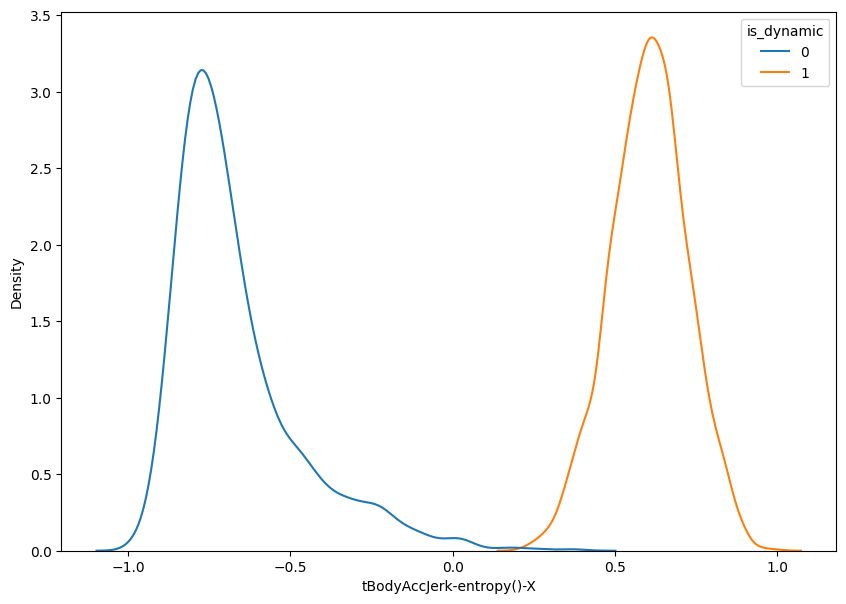

In [125]:
top_bottom_kde('tBodyAccJerk-entropy()-X')

# 해당 그래프의 경우, 0.2 미만은 정적, 0.2 초과는 동적 그래프라고 판단할 수 있다.

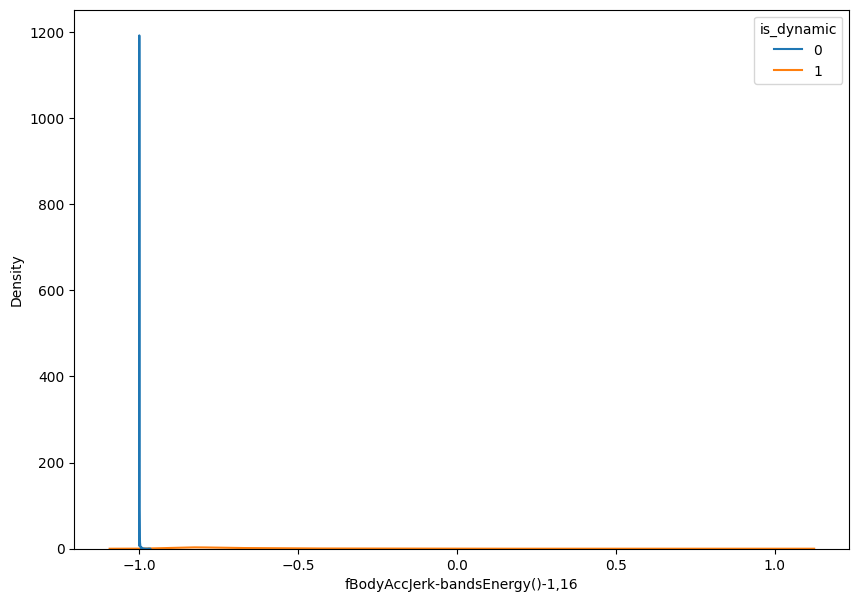

In [126]:
top_bottom_kde('fBodyAccJerk-bandsEnergy()-1,16')

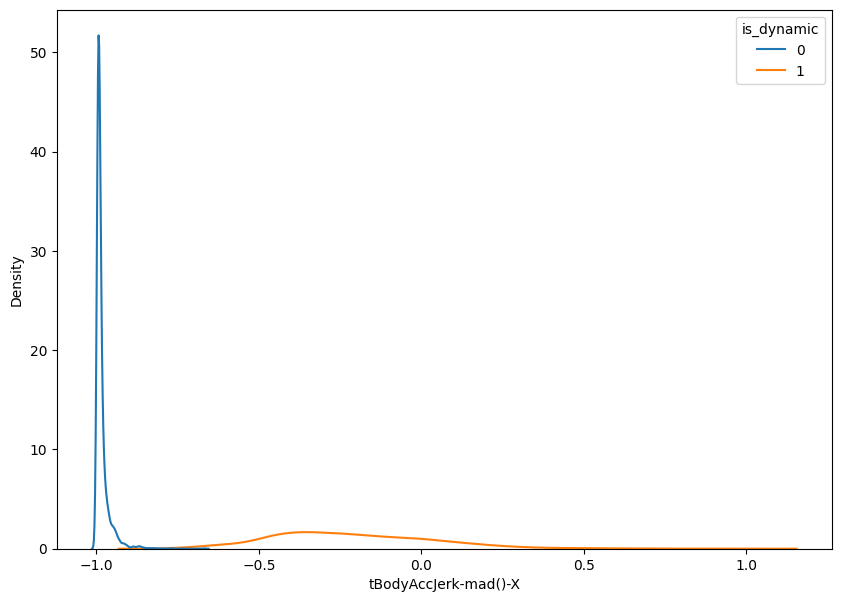

In [127]:
top_bottom_kde('tBodyAccJerk-mad()-X')

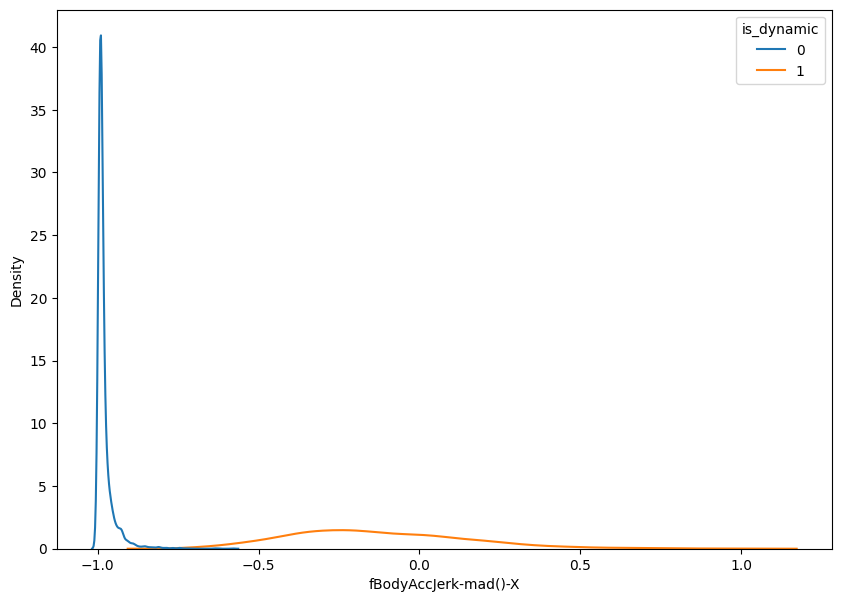

In [128]:
top_bottom_kde('fBodyAccJerk-mad()-X')

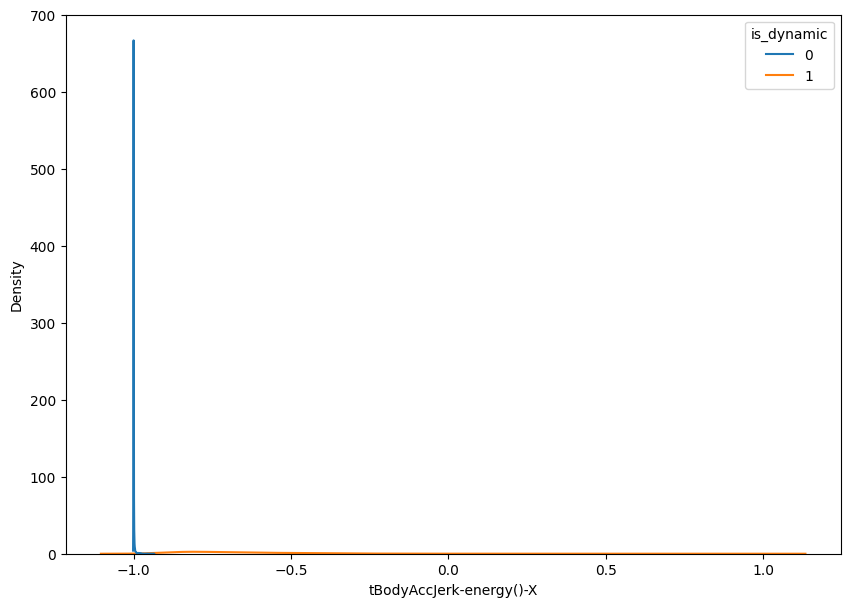

In [129]:
top_bottom_kde('tBodyAccJerk-energy()-X')